# 04. Interpretabilidad del Modelo con SHAP

Este notebook utiliza SHAP (SHapley Additive exPlanations) sobre el mejor modelo entrenado (`models/best_model.joblib`) para analizar qué características físicas y de control tienen un mayor impacto en la predicción del porcentaje de sílice en el concentrado final (`% Silica Concentrate`).

## Objetivos:
1. **Explicación global del modelo:** Identificar cuáles son las variables principales que determinan la predicción.
2. **Entender el sentido de impacto:** Analizar si valores altos o bajos de variables clave aumentan o disminuyen el porcentaje de sílice en el concentrado.
3. **Generación del Summary Plot:** Exportar un gráfico de tipo *beeswarm* a `reports/figuras/shap_summary.png` para usarlo en la documentación y presentación del proyecto (como en el archivo `README.md`).

## Consideraciones de rendimiento:
Dado que el set de prueba tiene un tamaño grande (~147k registros), el cálculo de valores SHAP para todas las muestras en un Random Forest completo es computacionalmente costoso. Por ello, seleccionaremos una muestra aleatoria representativa de **1000 observaciones** para realizar el análisis de forma eficiente y rápida.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns

print("SHAP version:", shap.__version__)
print("Pandas version:", pd.__version__)

SHAP version: 0.52.0
Pandas version: 3.0.2


In [2]:
model_dict = joblib.load('../models/best_model.joblib')
model = model_dict['model']
features = model_dict['features']

test_path = '../data/processed/test_engineered.parquet'
print(f"Cargando conjunto de prueba desde {test_path}...")
test_df = pd.read_parquet(test_path)

X_test = test_df[features].copy()
y_test = test_df['% Silica Concentrate'].copy()

print(f"\nModelo cargado: {type(model)}")
print(f"Características esperadas por el modelo: {len(features)}")
print(f"Dimensiones de X_test: {X_test.shape}")

Cargando conjunto de prueba desde ../data/processed/test_engineered.parquet...

Modelo cargado: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Características esperadas por el modelo: 117
Dimensiones de X_test: (147600, 117)


In [3]:
# Selección de muestra aleatoria para acelerar el cálculo de SHAP
sample_size = 1000
X_sample = X_test.sample(n=sample_size, random_state=42).copy()

print(f"Muestra aleatoria de {sample_size} registros creada.")
print(f"Dimensiones de la muestra: {X_sample.shape}")

Muestra aleatoria de 1000 registros creada.
Dimensiones de la muestra: (1000, 117)


In [4]:
# Instanciar el explicador de árboles
print("Instanciando shap.TreeExplainer con el modelo Random Forest...")
explainer = shap.TreeExplainer(model)

print("Calculando valores SHAP para la muestra (esto tomará unos segundos)...")
shap_values = explainer(X_sample)

print("¡Valores SHAP calculados con éxito!")
print(f"Dimensiones de los valores SHAP: {shap_values.shape}")

Instanciando shap.TreeExplainer con el modelo Random Forest...
Calculando valores SHAP para la muestra (esto tomará unos segundos)...
¡Valores SHAP calculados con éxito!
Dimensiones de los valores SHAP: (1000, 117)


Gráfico guardado exitosamente en: ../reports/figuras\shap_summary.png


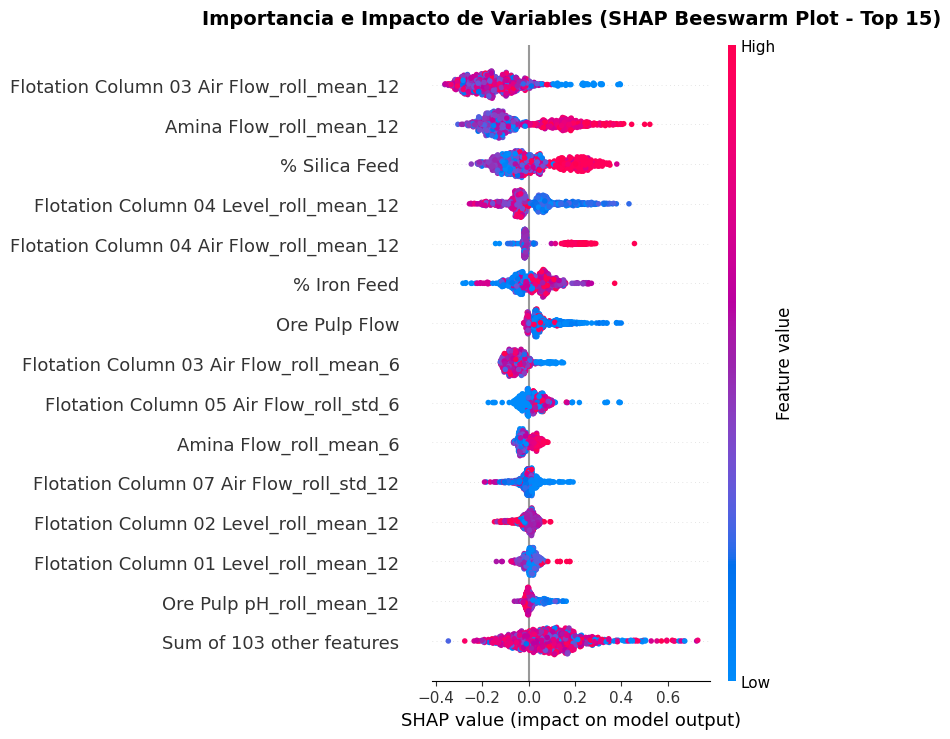

In [5]:
# Configurar el tamaño de la figura para una visualización clara
plt.figure(figsize=(12, 8))

# Generar el gráfico summary de tipo beeswarm
# Nota: Pasamos show=False para poder guardar y personalizar el título con matplotlib
shap.plots.beeswarm(shap_values, max_display=15, show=False)

# Crear directorio de reportes si no existe
output_dir = '../reports/figuras'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'shap_summary.png')

plt.title("Importancia e Impacto de Variables (SHAP Beeswarm Plot - Top 15)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Guardar a alta resolución (300 DPI) para el README
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Gráfico guardado exitosamente en: {output_path}")
plt.show()

In [6]:
# Obtener la importancia global promedio absoluta de SHAP por variable
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': features,
    'Mean Abs SHAP': mean_abs_shap
}).sort_values(by='Mean Abs SHAP', ascending=False).reset_index(drop=True)

print("Top 15 características con mayor impacto global (SHAP absoluto promedio):")
print(importance_df.head(15))

Top 15 características con mayor impacto global (SHAP absoluto promedio):
                                      Feature  Mean Abs SHAP
0   Flotation Column 03 Air Flow_roll_mean_12       0.165751
1                     Amina Flow_roll_mean_12       0.149516
2                               % Silica Feed       0.111658
3      Flotation Column 04 Level_roll_mean_12       0.081879
4   Flotation Column 04 Air Flow_roll_mean_12       0.065005
5                                 % Iron Feed       0.063693
6                               Ore Pulp Flow       0.062687
7    Flotation Column 03 Air Flow_roll_mean_6       0.059695
8     Flotation Column 05 Air Flow_roll_std_6       0.038674
9                      Amina Flow_roll_mean_6       0.028106
10   Flotation Column 07 Air Flow_roll_std_12       0.025611
11     Flotation Column 02 Level_roll_mean_12       0.024602
12     Flotation Column 01 Level_roll_mean_12       0.023064
13                   Ore Pulp pH_roll_mean_12       0.021566
14         